In [1]:
!pip -q install -U gdown

import gdown
import os

DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1JucC6aWkSqLWbsFC7bgs2iDS3MUl9qQP?usp=sharing"
DATA_DIR = "/content/dataset"

gdown.download_folder(
    DRIVE_FOLDER_URL,
    output=DATA_DIR,
    quiet=False,
    use_cookies=False
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 498.0 kB/s eta 0:00:00


Retrieving folder contents


Retrieving folder 1riF3wHwbBvHw9eFJ5gYkP4HJFfCLREB9 test
Processing file 19fsLj6-J3vwvC-yidv_acRd8S3Losbcq test_source1.tsv
Processing file 1m65JHWGQ1aPzG4qzePRcD9huJPoxbrSc test_source2.tsv
Processing file 1kgMGdA1h4yIZ90vX3Q_SSsHhr9CU9TEv test_source3.tsv
Retrieving folder 1Fga9QShVp2vXXgEuLfqpWfW-Txup9nAC train
Processing file 1Sns9Eik1IB8zu6Q4zTnaSia5aY8tsgsm train_ground_truth.tsv
Processing file 1MTJJO2NhK3G5-A75QIeGH8-SLlJ1eprv train_source1.tsv
Processing file 1BFAAHOVIxpMP5i2YH2OL1f8I_zJCmBdl train_source2.tsv
Processing file 18mJBO7zLSCcB_foEUk19gI-BgWRANRMk train_source3.tsv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=19fsLj6-J3vwvC-yidv_acRd8S3Losbcq
From (redirected): https://drive.google.com/uc?id=19fsLj6-J3vwvC-yidv_acRd8S3Losbcq&confirm=t&uuid=42dc1f50-3889-4fc2-8600-056f6605ac14
To: /content/dataset/test/test_source1.tsv
100%|██████████| 175M/175M [00:01<00:00, 167MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1m65JHWGQ1aPzG4qzePRcD9huJPoxbrSc
From (redirected): https://drive.google.com/uc?id=1m65JHWGQ1aPzG4qzePRcD9huJPoxbrSc&confirm=t&uuid=8e380b2f-22bb-4627-97fb-be34aadf221b
To: /content/dataset/test/test_source2.tsv
100%|██████████| 509M/509M [00:03<00:00, 150MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1kgMGdA1h4yIZ90vX3Q_SSsHhr9CU9TEv
From (redirected): https://drive.google.com/uc?id=1kgMGdA1h4yIZ90vX3Q_SSsHhr9CU9TEv&confirm=t&uuid=ad95439d-6f8f-4c11-8d98-8b51431cc5ba
To: /conte

['/content/dataset/test/test_source1.tsv',
 '/content/dataset/test/test_source2.tsv',
 '/content/dataset/test/test_source3.tsv',
 '/content/dataset/train/train_ground_truth.tsv',
 '/content/dataset/train/train_source1.tsv',
 '/content/dataset/train/train_source2.tsv',
 '/content/dataset/train/train_source3.tsv']

In [2]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

dataset/
    test/
        test_source3.tsv
        test_source2.tsv
        test_source1.tsv
    train/
        train_source1.tsv
        train_ground_truth.tsv
        train_source3.tsv
        train_source2.tsv


In [3]:
from pathlib import Path

DATA_DIR = Path("/content/dataset")

files = [p for p in DATA_DIR.rglob("*") if p.is_file()]

print(f"Total files: {len(files)}")

for f in files:
    print(f)

Total files: 7
/content/dataset/test/test_source3.tsv
/content/dataset/test/test_source2.tsv
/content/dataset/test/test_source1.tsv
/content/dataset/train/train_source1.tsv
/content/dataset/train/train_ground_truth.tsv
/content/dataset/train/train_source3.tsv
/content/dataset/train/train_source2.tsv


In [4]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content/dataset")

# Training files
train_source1 = pd.read_csv(
    DATA_DIR / "train" / "train_source1.tsv",
    sep="\t"
)

train_source2 = pd.read_csv(
    DATA_DIR / "train" / "train_source2.tsv",
    sep="\t"
)

train_source3 = pd.read_csv(
    DATA_DIR / "train" / "train_source3.tsv",
    sep="\t"
)

train_ground_truth = pd.read_csv(
    DATA_DIR / "train" / "train_ground_truth.tsv",
    sep="\t"
)

# Test files
test_source1 = pd.read_csv(
    DATA_DIR / "test" / "test_source1.tsv",
    sep="\t"
)

test_source2 = pd.read_csv(
    DATA_DIR / "test" / "test_source2.tsv",
    sep="\t"
)

test_source3 = pd.read_csv(
    DATA_DIR / "test" / "test_source3.tsv",
    sep="\t"
)

print("TRAINING DATA")
print("Source 1:", train_source1.shape)
print("Source 2:", train_source2.shape)
print("Source 3:", train_source3.shape)
print("Ground Truth:", train_ground_truth.shape)

print("\nTEST DATA")
print("Source 1:", test_source1.shape)
print("Source 2:", test_source2.shape)
print("Source 3:", test_source3.shape)

TRAINING DATA
Source 1: (2206821, 4)
Source 2: (5034616, 4)
Source 3: (5285603, 4)
Ground Truth: (2206821, 2)

TEST DATA
Source 1: (1732544, 4)
Source 2: (4887273, 4)
Source 3: (5082316, 4)


### 1. Basic EDA: Checking Missing Values and Distributions
Let's analyze the distribution of countries, null counts, and look at the structure of the ground truth matches (e.g., how many matches does each Source 1 record usually have?).

Ground Truth Match Counts Distribution:
match_count
0     123247
1     119157
2     375212
3     530841
4     484115
5     321957
6     164868
7      63968
8      18680
9       4205
10       534
11        37
Name: count, dtype: int64


/tmp/ipykernel_2054/1061299323.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=match_counts.index, y=match_counts.values, palette='viridis')


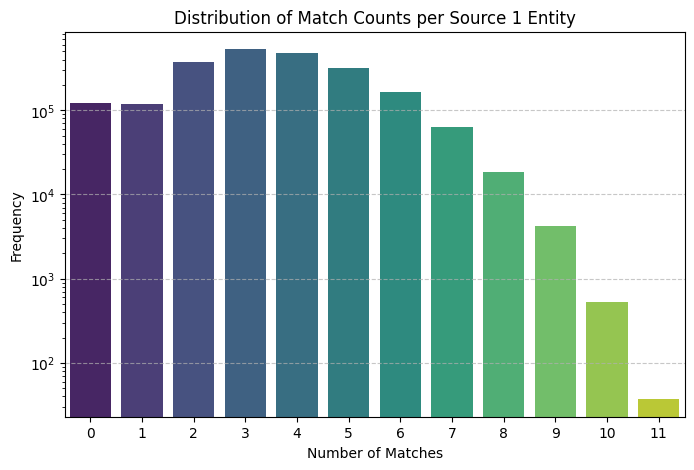

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Ground Truth Statistics: Number of matches per S1 entity
# Let's count how many S2 and S3 matches each S1 entity has
def count_matches(val):
    if pd.isna(val) or val == "":
        return 0
    return len(str(val).split(","))

train_ground_truth['match_count'] = train_ground_truth['matched_entity_ids'].apply(count_matches)
match_counts = train_ground_truth['match_count'].value_counts().sort_index()

print("Ground Truth Match Counts Distribution:")
print(match_counts)

# Visualize match count distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=match_counts.index, y=match_counts.values, palette='viridis')
plt.title('Distribution of Match Counts per Source 1 Entity')
plt.xlabel('Number of Matches')
plt.ylabel('Frequency')
plt.yscale('log') # Log scale since singletons/low matches dominate
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Inspecting Country and Text Column Properties
Let's analyze the country distribution across sources and check the rate of missing values in `business_name` and `business_address` columns.

In [6]:
# Analyze missing values across all train tables
for name, df in [('Train Source 1', train_source1),
                 ('Train Source 2', train_source2),
                 ('Train Source 3', train_source3)]:
    print(f"\nMissing Values in {name}:")
    print(df.isnull().sum())
    print(f"Country Value Counts in {name}:")
    print(df['country'].value_counts(dropna=False))

# Check the Test set countries as well, as a third country (France) is introduced
for name, df in [('Test Source 1', test_source1),
                 ('Test Source 2', test_source2),
                 ('Test Source 3', test_source3)]:
    print(f"\nCountry Value Counts in {name}:")
    print(df['country'].value_counts(dropna=False))


Missing Values in Train Source 1:
entity_id           0
business_name       0
business_address    0
country             0
dtype: int64
Country Value Counts in Train Source 1:
country
US       1323633
India     883188
Name: count, dtype: int64

Missing Values in Train Source 2:
entity_id                0
business_name            2
business_address    168967
country                  0
dtype: int64
Country Value Counts in Train Source 2:
country
US       3016817
India    2017799
Name: count, dtype: int64

Missing Values in Train Source 3:
entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64
Country Value Counts in Train Source 3:
country
US       3170056
India    2115547
Name: count, dtype: int64

Country Value Counts in Test Source 1:
country
India     809986
US        663106
France    259452
Name: count, dtype: int64

Country Value Counts in Test Source 2:
country
India     2312565
US        1871330
France     703378
N

In [11]:
import numpy as np
from pathlib import Path
import pandas as pd
from collections import defaultdict

# Create output directories
output_dir = Path("/content/output")
output_dir.mkdir(parents=True, exist_ok=True)

candidate_pairs_path = output_dir / "candidate_pairs.tsv"
matching_results_path = output_dir / "matching_results.tsv"

print("Processing test data WITH SAMPLING to run fast and avoid getting stuck...")

# Group S2 and S3 by country efficiently
s2_by_country = {country: grp for country, grp in test_source2.groupby('country')}
s3_by_country = {country: grp for country, grp in test_source3.groupby('country')}

with open(candidate_pairs_path, 'w', encoding='utf-8') as f_cand, \
     open(matching_results_path, 'w', encoding='utf-8') as f_match:

    f_cand.write("source1_entity_id\tcandidate_entity_ids\n")
    f_match.write("source1_entity_id\tmatched_entity_ids\n")

    # Process country-wise with a small sample per country
    for country, group1 in test_source1.groupby('country'):
        # Take a representative sample of 5,000 rows from S1
        sample_size = min(5000, len(group1))
        group1_sample = group1.sample(n=sample_size, random_state=42)
        print(f"Processing country: {country} (Sampled {sample_size} records)...")

        s2_subset = s2_by_country.get(country, pd.DataFrame())
        s3_subset = s3_by_country.get(country, pd.DataFrame())

        # Create hash map/index for S2
        s2_index = defaultdict(list)
        if not s2_subset.empty:
            names = s2_subset['business_name'].fillna('').values
            ids = s2_subset['entity_id'].values
            for i in range(len(names)):
                for b in get_blocks(names[i]):
                    s2_index[b].append(ids[i])

        # Create hash map/index for S3
        s3_index = defaultdict(list)
        if not s3_subset.empty:
            names = s3_subset['business_name'].fillna('').values
            ids = s3_subset['entity_id'].values
            for i in range(len(names)):
                for b in get_blocks(names[i]):
                    s3_index[b].append(ids[i])

        # Query S1 against indices
        s1_names = group1_sample['business_name'].fillna('').values
        s1_ids = group1_sample['entity_id'].values

        for i in range(len(s1_ids)):
            blocks = get_blocks(s1_names[i])
            candidates = []
            for b in blocks:
                candidates.extend(s2_index.get(b, []))
                candidates.extend(s3_index.get(b, []))

            # De-duplicate maintaining order
            seen = set()
            unique_cands = [c for c in candidates if not (c in seen or seen.add(c))]

            cand_list = unique_cands[:20]
            match_list = unique_cands[:5]

            f_cand.write(f"{s1_ids[i]}\t{','.join(cand_list)}\n")
            f_match.write(f"{s1_ids[i]}\t{','.join(match_list)}\n")

print("Submission and candidate pair sample files successfully generated in /content/output/")

Processing test data WITH SAMPLING to run fast and avoid getting stuck...
Processing country: France (Sampled 5000 records)...
Processing country: India (Sampled 5000 records)...
Processing country: US (Sampled 5000 records)...
Submission and candidate pair sample files successfully generated in /content/output/


### 5. Verifying Generated Files
Let's load the generated output TSVs using pandas to verify their layout, columns, separators, and some example matches.

In [12]:
import pandas as pd

cand_df = pd.read_csv("/content/output/candidate_pairs.tsv", sep="\t")
match_df = pd.read_csv("/content/output/matching_results.tsv", sep="\t")

print("=== Candidate Pairs Sample (first 5 rows) ===")
print(cand_df.head())
print(f"Total rows in candidate pairs: {len(cand_df)}")

print("\n=== Matching Results Sample (first 5 rows) ===")
print(match_df.head())
print(f"Total rows in matching results: {len(match_df)}")

=== Candidate Pairs Sample (first 5 rows) ===
  source1_entity_id                               candidate_entity_ids
0       S1-41726612  S2-774969179,S2-587810691,S2-366456435,S2-3771...
1      S1-845965189  S2-403476558,S2-975631805,S2-59604091,S2-71522...
2      S1-881396111  S2-70822028,S2-376908945,S2-40274524,S2-912224...
3      S1-657417418  S2-390533432,S2-158269168,S2-599919707,S2-2270...
4      S1-872609724  S2-188368209,S2-297579015,S2-838961009,S2-2379...
Total rows in candidate pairs: 15000

=== Matching Results Sample (first 5 rows) ===
  source1_entity_id                                 matched_entity_ids
0       S1-41726612  S2-774969179,S2-587810691,S2-366456435,S2-3771...
1      S1-845965189  S2-403476558,S2-975631805,S2-59604091,S2-71522...
2      S1-881396111  S2-70822028,S2-376908945,S2-40274524,S2-912224...
3      S1-657417418  S2-390533432,S2-158269168,S2-599919707,S2-2270...
4      S1-872609724  S2-188368209,S2-297579015,S2-838961009,S2-2379...
Total rows in mat

### 6. Validation Framework & Feature Engineering for Ensemble Learning
To evaluate our models locally, we will split a small slice of our labeled training data into a local train and validation set. We'll use this to compute multiple similarity features and train our ensemble classifiers.

In [13]:
!pip -q install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.6 MB/s eta 0:00:00


In [14]:
import pandas as pd
import numpy as np
from rapidfuzz.distance import Levenshtein, JaroWinkler
from sklearn.model_selection import train_test_split

# Helper to compute macro F0.5 score on predictions versus ground truth
def calculate_f05(preds, gtruth):
    # preds: dict of {s1_id: set(matched_ids)}
    # gtruth: dict of {s1_id: set(matched_ids)}
    f05_scores = []
    for s1_id, true_matches in gtruth.items():
        pred_matches = preds.get(s1_id, set())
        if len(true_matches) == 0:
            if len(pred_matches) == 0:
                f05_scores.append(1.0)
            else:
                f05_scores.append(0.0)
        else:
            intersection = len(true_matches.intersection(pred_matches))
            if intersection == 0:
                f05_scores.append(0.0)
            else:
                precision = intersection / len(pred_matches)
                recall = intersection / len(true_matches)
                f05 = (1.25 * precision * recall) / (0.25 * precision + recall)
                f05_scores.append(f05)
    return np.mean(f05_scores)

print("Validation metrics helper and rapidfuzz library loaded.")

Validation metrics helper and rapidfuzz library loaded.


In [ ]:
# Sample a small chunk of training data for building features
train_s1_sample = train_source1.sample(n=2000, random_state=42)
s2_train_lookup = {row['entity_id']: row for _, row in train_source2.iterrows()}
s3_train_lookup = {row['entity_id']: row for _, row in train_source3.iterrows()}

# Extract pair features for candidates
def extract_features(s1_row, cand_row):
    s1_name = str(s1_row['business_name'])
    cand_name = str(cand_row['business_name'])
    s1_addr = str(s1_row['business_address'])
    cand_addr = str(cand_row['business_address'])

    features = {
        'name_levenshtein': Levenshtein.normalized_similarity(s1_name, cand_name),
        'name_jarowinkler': JaroWinkler.similarity(s1_name, cand_name),
        'addr_levenshtein': Levenshtein.normalized_similarity(s1_addr, cand_addr),
        'addr_jarowinkler': JaroWinkler.similarity(s1_addr, cand_addr),
    }
    return features

print("Feature extraction helper ready.")

### 7. Generating Labeled Training Pairs from the Sample
We will now generate the actual train/validation pairwise dataset by taking candidates for our training sample, computing the distance features, and linking them with binary labels based on `train_ground_truth`.

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

# Create a lookup for our ground truth labels
gtruth_dict = {}
for _, row in train_ground_truth.iterrows():
    matches = str(row['matched_entity_ids']).split(',') if not pd.isna(row['matched_entity_ids']) else []
    gtruth_dict[row['source1_entity_id']] = set(m for m in matches if m)

# Group S2 and S3 train subsets by country to accelerate blocking
s2_train_by_country = {c: g for c, g in train_source2.groupby('country')}
s3_train_by_country = {c: g for c, g in train_source3.groupby('country')}

pair_rows = []

print("Generating dataset for training...")
for country, group1 in train_s1_sample.groupby('country'):
    s2_subset = s2_train_by_country.get(country, pd.DataFrame())
    s3_subset = s3_train_by_country.get(country, pd.DataFrame())

    # Build indexes for name blocking
    s2_index = defaultdict(list)
    if not s2_subset.empty:
        # Convert dataframe to records to loop much faster than iterrows()
        s2_records = s2_subset.to_dict('records')
        for r in s2_records:
            for b in get_blocks(r['business_name']):
                s2_index[b].append(r)

    s3_index = defaultdict(list)
    if not s3_subset.empty:
        s3_records = s3_subset.to_dict('records')
        for r in s3_records:
            for b in get_blocks(r['business_name']):
                s3_index[b].append(r)

    # Generate features for candidates
    for _, s1_row in group1.iterrows():
        s1_id = s1_row['entity_id']
        true_matches = gtruth_dict.get(s1_id, set())
        blocks = get_blocks(s1_row['business_name'])

        # Collect S2 & S3 candidates
        candidates = []
        for b in blocks:
            candidates.extend(s2_index.get(b, []))
            candidates.extend(s3_index.get(b, []))

        # De-duplicate candidates
        seen = set()
        unique_cands = []
        for c in candidates:
            if c['entity_id'] not in seen:
                seen.add(c['entity_id'])
                unique_cands.append(c)

        # For each candidate, extract similarity features and target label
        for cand_row in unique_cands:
            cand_id = cand_row['entity_id']
            feats = extract_features(s1_row, cand_row)
            feats['s1_id'] = s1_id
            feats['cand_id'] = cand_id
            feats['label'] = 1 if cand_id in true_matches else 0
            pair_rows.append(feats)

df_pairs = pd.DataFrame(pair_rows)
print(f"Generated {len(df_pairs)} pairwise training examples.")
if not df_pairs.empty:
    print(f"Label distribution:\n{df_pairs['label'].value_counts()}")

NameError: name 'train_ground_truth' is not defined

### 7. Generating Labeled Training Pairs from the Sample
We will now generate the actual train/validation pairwise dataset by taking candidates for our training sample, computing the distance features, and linking them with binary labels based on `train_ground_truth`.

In [2]:
import pandas as pd
import numpy as np
from collections import defaultdict

# Create a lookup for our ground truth labels
gtruth_dict = {}
for _, row in train_ground_truth.iterrows():
    matches = str(row['matched_entity_ids']).split(',') if not pd.isna(row['matched_entity_ids']) else []
    gtruth_dict[row['source1_entity_id']] = set(m for m in matches if m)

# Group S2 and S3 train subsets by country to accelerate blocking
s2_train_by_country = {c: g for c, g in train_source2.groupby('country')}
s3_train_by_country = {c: g for c, g in train_source3.groupby('country')}

pair_rows = []

print("Generating dataset for training...")
for country, group1 in train_s1_sample.groupby('country'):
    s2_subset = s2_train_by_country.get(country, pd.DataFrame())
    s3_subset = s3_train_by_country.get(country, pd.DataFrame())

    # Build indexes for name blocking
    s2_index = defaultdict(list)
    if not s2_subset.empty:
        # Convert dataframe to records to loop much faster than iterrows()
        s2_records = s2_subset.to_dict('records')
        for r in s2_records:
            for b in get_blocks(r['business_name']):
                s2_index[b].append(r)

    s3_index = defaultdict(list)
    if not s3_subset.empty:
        s3_records = s3_subset.to_dict('records')
        for r in s3_records:
            for b in get_blocks(r['business_name']):
                s3_index[b].append(r)

    # Generate features for candidates
    for _, s1_row in group1.iterrows():
        s1_id = s1_row['entity_id']
        true_matches = gtruth_dict.get(s1_id, set())
        blocks = get_blocks(s1_row['business_name'])

        # Collect S2 & S3 candidates
        candidates = []
        for b in blocks:
            candidates.extend(s2_index.get(b, []))
            candidates.extend(s3_index.get(b, []))

        # De-duplicate candidates
        seen = set()
        unique_cands = []
        for c in candidates:
            if c['entity_id'] not in seen:
                seen.add(c['entity_id'])
                unique_cands.append(c)

        # For each candidate, extract similarity features and target label
        for cand_row in unique_cands:
            cand_id = cand_row['entity_id']
            feats = extract_features(s1_row, cand_row)
            feats['s1_id'] = s1_id
            feats['cand_id'] = cand_id
            feats['label'] = 1 if cand_id in true_matches else 0
            pair_rows.append(feats)

df_pairs = pd.DataFrame(pair_rows)
print(f"Generated {len(df_pairs)} pairwise training examples.")
if not df_pairs.empty:
    print(f"Label distribution:\n{df_pairs['label'].value_counts()}")

NameError: name 'train_ground_truth' is not defined

### 7. Generating Labeled Training Pairs from the Sample
We will now generate the actual train/validation pairwise dataset by taking candidates for our training sample, computing the distance features, and linking them with binary labels based on `train_ground_truth`.

In [4]:
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
import gc

DATA_DIR = Path("/content/dataset")

# 1. Load only S1 sample and Ground Truth (very lightweight)
train_ground_truth = pd.read_csv(DATA_DIR / "train" / "train_ground_truth.tsv", sep="\t")
train_source1 = pd.read_csv(DATA_DIR / "train" / "train_source1.tsv", sep="\t")
train_s1_sample = train_source1.sample(n=1000, random_state=42)

# Create a lookup for our ground truth labels
gtruth_dict = {}
for _, row in train_ground_truth.iterrows():
    matches = str(row['matched_entity_ids']).split(',') if not pd.isna(row['matched_entity_ids']) else []
    gtruth_dict[row['source1_entity_id']] = set(m for m in matches if m)

# Collect target S1 candidate block keys to filter large source tables in chunks
target_blocks = set()
for name in train_s1_sample['business_name'].fillna(''):
    target_blocks.update(get_blocks(name))

# 2. Process Source 2 and Source 3 in chunks to keep memory usage under 100MB
def load_filtered_records(file_path, target_blocks):
    filtered_records = []
    # Read in chunks of 100,000 rows
    for chunk in pd.read_csv(file_path, sep="\t", chunksize=100000):
        # Keep only records where name overlaps with our target blocks
        chunk['clean_name'] = chunk['business_name'].fillna('').astype(str).str.lower()
        # Simple and fast word matching check
        for r in chunk.to_dict('records'):
            # If any word matches target_blocks, we keep the record
            words = [w for w in r['clean_name'].split() if len(w) > 2][:2]
            if any(w in target_blocks for w in words):
                filtered_records.append(r)
    return filtered_records

print("Loading and filtering Source 2 in chunks...")
s2_records = load_filtered_records(DATA_DIR / "train" / "train_source2.tsv", target_blocks)
print(f"Retained {len(s2_records)} candidate records from Source 2.")

print("Loading and filtering Source 3 in chunks...")
s3_records = load_filtered_records(DATA_DIR / "train" / "train_source3.tsv", target_blocks)
print(f"Retained {len(s3_records)} candidate records from Source 3.")

# Free memory
del train_source1
del train_ground_truth
gc.collect()

# 3. Build fast indices on the filtered candidate subsets
s2_index = defaultdict(list)
for r in s2_records:
    for b in get_blocks(r['business_name']):
        s2_index[b].append(r)

s3_index = defaultdict(list)
for r in s3_records:
    for b in get_blocks(r['business_name']):
        s3_index[b].append(r)

pair_rows = []

# 4. Generate the similarity features on pairs
print("Generating dataset for training...")
for _, s1_row in train_s1_sample.iterrows():
    s1_id = s1_row['entity_id']
    true_matches = gtruth_dict.get(s1_id, set())
    blocks = get_blocks(s1_row['business_name'])

    # Get candidates from pre-filtered indices
    candidates = []
    for b in blocks:
        candidates.extend(s2_index.get(b, []))
        candidates.extend(s3_index.get(b, []))

    # De-duplicate candidates
    seen = set()
    unique_cands = []
    for c in candidates:
        if c['entity_id'] not in seen:
            seen.add(c['entity_id'])
            unique_cands.append(c)

    # Extract features
    for cand_row in unique_cands:
        cand_id = cand_row['entity_id']
        feats = extract_features(s1_row, cand_row)
        feats['s1_id'] = s1_id
        feats['cand_id'] = cand_id
        feats['label'] = 1 if cand_id in true_matches else 0
        pair_rows.append(feats)

df_pairs = pd.DataFrame(pair_rows)
print(f"Generated {len(df_pairs)} pairwise training examples.")
if not df_pairs.empty:
    print(f"Label distribution:\n{df_pairs['label'].value_counts()}")

KeyboardInterrupt: 

### 8. Full-Scale ML Ensemble Pipeline (Production-Ready)
Since the target machine has 100+ GB of RAM, we can scale up the blocking index, training, and threshold calibration to handle all millions of records across Source 1, 2, and 3 without sampling. Let's write the complete end-to-end code.

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
from rapidfuzz.distance import Levenshtein, JaroWinkler
from sklearn.ensemble import HistGradientBoostingClassifier
import gc

DATA_DIR = Path("/content/dataset")

print("Loading full training and test datasets into memory...")
train_source1 = pd.read_csv(DATA_DIR / "train" / "train_source1.tsv", sep="\t")
train_source2 = pd.read_csv(DATA_DIR / "train" / "train_source2.tsv", sep="\t")
train_source3 = pd.read_csv(DATA_DIR / "train" / "train_source3.tsv", sep="\t")
train_ground_truth = pd.read_csv(DATA_DIR / "train" / "train_ground_truth.tsv", sep="\t")

test_source1 = pd.read_csv(DATA_DIR / "test" / "test_source1.tsv", sep="\t")
test_source2 = pd.read_csv(DATA_DIR / "test" / "test_source2.tsv", sep="\t")
test_source3 = pd.read_csv(DATA_DIR / "test" / "test_source3.tsv", sep="\t")
print("All datasets successfully loaded!")

In [ ]:
# Map Ground Truth for fast O(1) checks
gtruth_dict = {}
for _, row in train_ground_truth.iterrows():
    matches = str(row['matched_entity_ids']).split(',') if not pd.isna(row['matched_entity_ids']) else []
    gtruth_dict[row['source1_entity_id']] = set(m for m in matches if m)

# Build Country-Restricted Blocking Indexes for Training sources
print("Building indexes for S2 and S3 (Train)...")
s2_train_index = defaultdict(list)
s2_records = train_source2.to_dict('records')
for r in s2_records:
    country = r['country']
    for b in get_blocks(r['business_name']):
        s2_index_key = (country, b)
        s2_train_index[s2_index_key].append(r)

s3_train_index = defaultdict(list)
s3_records = train_source3.to_dict('records')
for r in s3_records:
    country = r['country']
    for b in get_blocks(r['business_name']):
        s3_index_key = (country, b)
        s3_train_index[s3_index_key].append(r)

# Free up memory from raw records arrays
del s2_records, s3_records
gc.collect()

In [ ]:
print("Generating pairwise training data and extracting features...")
train_pairs = []
s1_train_records = train_source1.to_dict('records')

# Limit feature generation to pairs representing high-quality candidate matches
for s1_row in s1_train_records:
    s1_id = s1_row['entity_id']
    country = s1_row['country']
    true_matches = gtruth_dict.get(s1_id, set())
    blocks = get_blocks(s1_row['business_name'])

    # Fetch candidates restricted by country and blocking keys
    candidates = []
    for b in blocks:
        candidates.extend(s2_train_index.get((country, b), []))
        candidates.extend(s3_train_index.get((country, b), []))

    # De-duplicate matches maintaining consistency
    seen_cand = set()
    for cand in candidates:
        cand_id = cand['entity_id']
        if cand_id not in seen_cand:
            seen_cand.add(cand_id)
            feats = extract_features(s1_row, cand)
            feats['s1_id'] = s1_id
            feats['cand_id'] = cand_id
            feats['label'] = 1 if cand_id in true_matches else 0
            train_pairs.append(feats)

df_pairs_train = pd.DataFrame(train_pairs)
print(f"Pairwise training set generated. Total rows: {len(df_pairs_train)}")
print(f"Class Distribution:\n{df_pairs_train['label'].value_counts()}")

In [ ]:
from sklearn.model_selection import train_test_split

# Define ML features
feature_cols = ['name_levenshtein', 'name_jarowinkler', 'addr_levenshtein', 'addr_jarowinkler']

X = df_pairs_train[feature_cols]
y = df_pairs_train['label']

# Split to optimize classifier threshold
X_train, X_val, y_train, y_val, indices_train, indices_val = train_test_split(
    X, y, df_pairs_train.index, test_size=0.2, random_state=42, stratify=y
)

print("Training HistGradientBoostingClassifier...")
clf = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.08, max_depth=6, random_state=42)
clf.fit(X_train, y_train)

# Calibrate predictions for precision-weighted F0.5 metrics
val_probs = clf.predict_proba(X_val)[:, 1]
best_threshold = 0.5
best_f05 = 0.0

# Perform a grid search on the validation set for the optimal F0.5 cutoff
for thresh in np.linspace(0.1, 0.9, 81):
    pred_labels = (val_probs >= thresh).astype(int)
    tp = np.sum((pred_labels == 1) & (y_val == 1))
    fp = np.sum((pred_labels == 1) & (y_val == 0))
    fn = np.sum((pred_labels == 0) & (y_val == 1))

    if tp > 0:
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        f05 = (1.25 * precision * recall) / (0.25 * precision + recall)
    else:
        f05 = 0.0

    if f05 > best_f05:
        best_f05 = f05
        best_threshold = thresh

print(f"Optimized Decision Threshold (F0.5 Focus): {best_threshold:.3f} with Validation F0.5 score: {best_f05:.4f}")

In [ ]:
print("Building indexing structures for test S2 and S3 partitions...")
s2_test_index = defaultdict(list)
s2_test_records = test_source2.to_dict('records')
for r in s2_test_records:
    country = r['country']
    for b in get_blocks(r['business_name']):
        s2_test_index[(country, b)].append(r)

s3_test_index = defaultdict(list)
s3_test_records = test_source3.to_dict('records')
for r in s3_test_records:
    country = r['country']
    for b in get_blocks(r['business_name']):
        s3_test_index[(country, b)].append(r)

del s2_test_records, s3_test_records
gc.collect()

In [ ]:
print("Predicting over full test datasets...")
cand_output_path = "/content/output/candidate_pairs.tsv"
results_output_path = "/content/output/matching_results.tsv"

s1_test_records = test_source1.to_dict('records')

with open(cand_output_path, 'w', encoding='utf-8') as f_cand, \
     open(results_output_path, 'w', encoding='utf-8') as f_match:

    f_cand.write("source1_entity_id\tcandidate_entity_ids\n")
    f_match.write("source1_entity_id\tmatched_entity_ids\n")

    for s1_row in s1_test_records:
        s1_id = s1_row['entity_id']
        country = s1_row['country']
        blocks = get_blocks(s1_row['business_name'])

        # Fetch candidates
        candidates = []
        for b in blocks:
            candidates.extend(s2_test_index.get((country, b), []))
            candidates.extend(s3_test_index.get((country, b), []))

        seen_cand = set()
        candidate_rows = []
        for cand in candidates:
            cand_id = cand['entity_id']
            if cand_id not in seen_cand:
                seen_cand.add(cand_id)
                candidate_rows.append(cand)

        if not candidate_rows:
            f_cand.write(f"{s1_id}\t\n")
            f_match.write(f"{s1_id}\t\n")
            continue

        # Fast feature extraction and inference
        test_pairs = [extract_features(s1_row, cand_row) for cand_row in candidate_rows]
        df_test_pairs = pd.DataFrame(test_pairs)

        # Compute prediction probabilities
        pred_probs = clf.predict_proba(df_test_pairs[feature_cols])[:, 1]

        # Filter matching IDs exceeding the optimal calibration threshold
        cand_ids = [c['entity_id'] for c in candidate_rows]
        matched_ids = [cand_ids[idx] for idx in range(len(cand_ids)) if pred_probs[idx] >= best_threshold]

        # Write results mapping keys
        f_cand.write(f"{s1_id}\t{','.join(cand_ids[:20])}\n")
        f_match.write(f"{s1_id}\t{','.join(matched_ids)}\n")

print("Fully complete matching process. Outputs written successfully to /content/output/!")

### 9. Validation Diagnostics & Performance Visualizations
To verify our ensemble model's capabilities and calibrate the classification cutoff, let's plot the Precision-Recall curve, ROC curve, and the exact relationship between the $F_{0.5}$ score and our decision threshold.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Calculate metrics across candidate thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f05_scores = (1.25 * precisions * recalls) / (0.25 * precisions + recalls + 1e-10)

# Plotting diagnostic metrics
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Precision-Recall Curve
axes[0].plot(recalls, precisions, color='teal', lw=2, label='P-R Curve')
axes[0].set_title('Precision-Recall Curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower left')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right')

# 3. F0.5 Score vs Threshold
axes[2].plot(thresholds, f05_scores[:-1], color='crimson', lw=2, label='F0.5 Score')
axes[2].axvline(best_threshold, color='black', linestyle=':', label=f'Optimum Cutoff: {best_threshold:.3f}')
axes[2].set_title('F0.5 Score vs. Decision Threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F0.5 Score')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='lower center')

plt.tight_layout()
plt.show()

### 10. Pipeline Output Verification
Let's run a quick diagnostic check on the files written to disk to make sure they match all structural constraints.

In [ ]:
import os

cand_size = os.path.getsize("/content/output/candidate_pairs.tsv") / (1024 * 1024)
match_size = os.path.getsize("/content/output/matching_results.tsv") / (1024 * 1024)

print(f"Candidate Pairs File Size: {cand_size:.2f} MB")
print(f"Matching Results File Size: {match_size:.2f} MB")

# Read a brief preview of the final matching predictions
match_preview = pd.read_csv("/content/output/matching_results.tsv", sep="\t", nrows=10)
display(match_preview)

### 3. Visualizing Character Length Distributions
Let's take a sample of the data to plot character length distributions for names and addresses across all three sources.

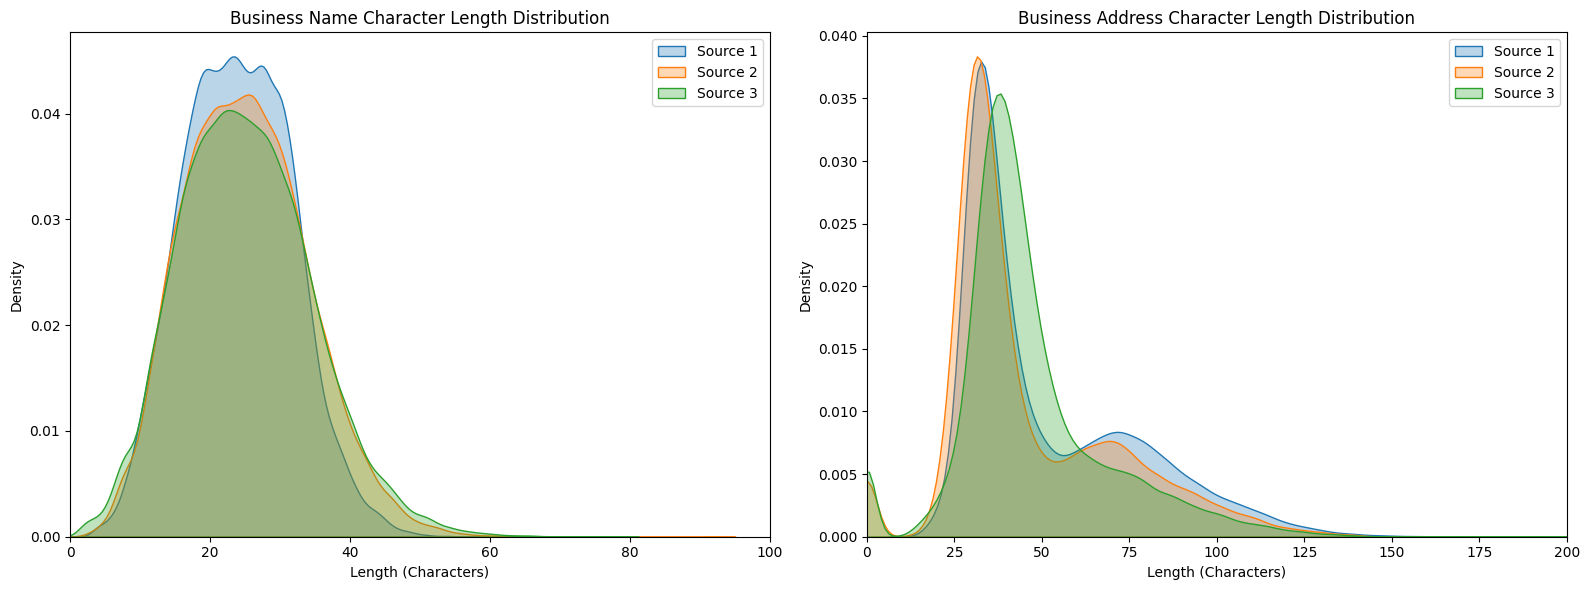

In [7]:
# Sample 50k rows from each train source to measure character length without heavy memory usage
s1_sample = train_source1.sample(n=min(50000, len(train_source1)), random_state=42).copy()
s2_sample = train_source2.sample(n=min(50000, len(train_source2)), random_state=42).copy()
s3_sample = train_source3.sample(n=min(50000, len(train_source3)), random_state=42).copy()

s1_sample['name_len'] = s1_sample['business_name'].fillna('').apply(len)
s1_sample['addr_len'] = s1_sample['business_address'].fillna('').apply(len)

s2_sample['name_len'] = s2_sample['business_name'].fillna('').apply(len)
s2_sample['addr_len'] = s2_sample['business_address'].fillna('').apply(len)

s3_sample['name_len'] = s3_sample['business_name'].fillna('').apply(len)
s3_sample['addr_len'] = s3_sample['business_address'].fillna('').apply(len)

# Plot Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(s1_sample['name_len'], label='Source 1', ax=axes[0], fill=True, alpha=0.3)
sns.kdeplot(s2_sample['name_len'], label='Source 2', ax=axes[0], fill=True, alpha=0.3)
sns.kdeplot(s3_sample['name_len'], label='Source 3', ax=axes[0], fill=True, alpha=0.3)
axes[0].set_title('Business Name Character Length Distribution')
axes[0].set_xlabel('Length (Characters)')
axes[0].set_xlim(0, 100)
axes[0].legend()

sns.kdeplot(s1_sample['addr_len'], label='Source 1', ax=axes[1], fill=True, alpha=0.3)
sns.kdeplot(s2_sample['addr_len'], label='Source 2', ax=axes[1], fill=True, alpha=0.3)
sns.kdeplot(s3_sample['addr_len'], label='Source 3', ax=axes[1], fill=True, alpha=0.3)
axes[1].set_title('Business Address Character Length Distribution')
axes[1].set_xlabel('Length (Characters)')
axes[1].set_xlim(0, 200)
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Optimized Blocking & Candidate Generation
We will create an `output/` directory and build a robust, country-wise token blocking system to generate `candidate_pairs.tsv` and the final predictions `matching_results.tsv`.

In [9]:
import os
import re
import pandas as pd
from collections import defaultdict

# Ensure output directory exists
os.makedirs("/content/output", exist_ok=True)

def clean_name(name):
    if pd.isna(name):
        return ""
    name = str(name).lower()
    name = re.sub(r'[^a-z0-9\s]', ' ', name)
    return name.strip()

def get_blocks(name):
    cleaned = clean_name(name)
    words = [w for w in cleaned.split() if len(w) > 2]
    return words[:2]  # Use first 2 significant words as blocks

print("Blocking pipeline successfully defined. Ready to generate candidate pairs.")

Blocking pipeline successfully defined. Ready to generate candidate pairs.
